In [1]:
# In this example, the initial domain is constructed using a 2D survival map
# First, escaping initial conditions are selected, and their complete orbits are used to construct the initial domain
# This domain can then be used to initialize the iterative procedure or grown directly without ray filtering

In [2]:
# Import 

from tqdm import tqdm

import numpy as np
from numpy.typing import NDArray
from numba import njit

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

from domain.scan import iterate
from domain.scan import count
from domain.scan import scan
from domain.scan import orbit

from domain.da import da
from domain.da import refine

from domain.volume import rays
from domain.volume import directions
from domain.volume import volume
from domain.volume import mean

from domain.sample import sample
from domain.sample import mask
from domain.sample import filter
from domain.sample import select
from domain.domain import Domain

from domain import Configuration
from domain import Result
from domain import compute

In [3]:
# Set global parameters

dimension = 4                            # -- phase-space dimension
dl = 0.01                                # -- domain cell side length
dr = dl*dimension**0.5                   # -- radial step size
lb = np.array([-1.5, -1.5, -1.5, -1.5])  # -- domain lower bounds for (qx, qy, px, py)
ub = np.array([+1.5, +1.5, +1.5, +1.5])  # -- domain upper bounds for (qx, qy, px, py)
size = 131072                            # -- total number of iterations
ndirections = 8                          # -- number of initial random directions
nsamples = 512                           # -- number of random marked cells selected from the current marked cells
npoints = 8                              # -- number of random points to generate for each selected cell
nrounds = 128                            # -- maximum number of expansion rounds to perform
nepochs = 32                             # -- number of domain computations (MC over initial directions and expansion)
center = np.array([0., 0., 0., 0])       # -- domain center
cut = 1.0                                # -- selection cut radius
threshold = 5.0                          # -- threshold radius (an initial condition with larger radius is considered lost)
termination = 0.99                       # -- termination parameter (fraction of rays hitting marked domain cells)
scale = 3.0                              # -- perturbation scaling factor for new sample generation
bins_plane = 16                          # -- number of bins for the mixing coordinate
bins_phase = 32                          # -- number of bins for the in-plane phases
phase_threshold = 1.0E-3                 # -- phase threshold used in weighted selection
alpha_plane = 1.0                        # -- plane weight factor
alpha_phase = 0.5                        # -- phase weight factor
boost = 0.5                              # -- weight boost near the edges
delta = 1.0                              # -- inverse-density score regularization
uniform = 0.05                           # -- fraction of uniform sampling to use
power = 1.0                              # -- score power
uniform = 0.05                           # -- fraction of uniform sampling

In [4]:
# Define forward and inverse Henon maps

@njit
def forward4d(
    x:NDArray[np.float64], 
    parameters:NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Forward 4D Henon symplectic mapping

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx + sx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2))
    Qy = cy*qy + sy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3))
    Px = cx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2)) - sx*qx
    Py = cy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3)) - sy*qy
    return np.array([Qx, Qy, Px, Py])


@njit
def inverse4d(
    x: NDArray[np.float64], 
    parameters: NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Accelerator mapping (Henon) symplectic mapping (inverse)

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx - sx*px
    Qy = cy*qy - sy*py
    Px = cx*px + sx*qx - Qx**2 + Qy**2 - mu*(Qx**3 - 3*Qx*Qy**2)
    Py = cy*py + sy*qy + 2*Qx*Qy - mu*(-3*Qx**2*Qy + Qy**3)
    return np.array([Qx, Qy, Px, Py])

In [5]:
# Set mapping parameters

nux, nuy = 0.28, 0.31
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])

In [6]:
# Test mapping

print(forward4d(center, knobs))

[ 0.  0. -0. -0.]


In [7]:
# Define the objective function

objective = iterate(size, threshold, forward4d)

print(objective(center + 0.0*threshold, knobs))
print(objective(center + 1.0*threshold, knobs))

True
False


In [8]:
# Define the complexity function (number of stable iterations)

complexity_forward = count(size, threshold, forward4d)
complexity_inverse = count(size, threshold, inverse4d)

print(complexity_forward(center + 0.0*threshold, knobs))
print(complexity_forward(center + 1.0*threshold, knobs))

131072
0


In [9]:
# Survival map (forward and inverse)

n = 250
qx = np.linspace(-1.5, 1.5, n)
qy = np.linspace(-1.5, 1.5, n)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxqy_forward = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy_forward, complexity_forward, knobs)

mask_qxqy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy_inverse, complexity_inverse, knobs)

In [10]:
# Construct initial conditions

nmin = 32
nmax = 131072

select_forward = (np.log10(1 + mask_qxqy_forward) >= np.log10(nmin)) * (np.log10(1 + mask_qxqy_forward) <= np.log10(nmax))
select_inverse = (np.log10(1 + mask_qxqy_inverse) >= np.log10(nmin)) * (np.log10(1 + mask_qxqy_inverse) <= np.log10(nmax))

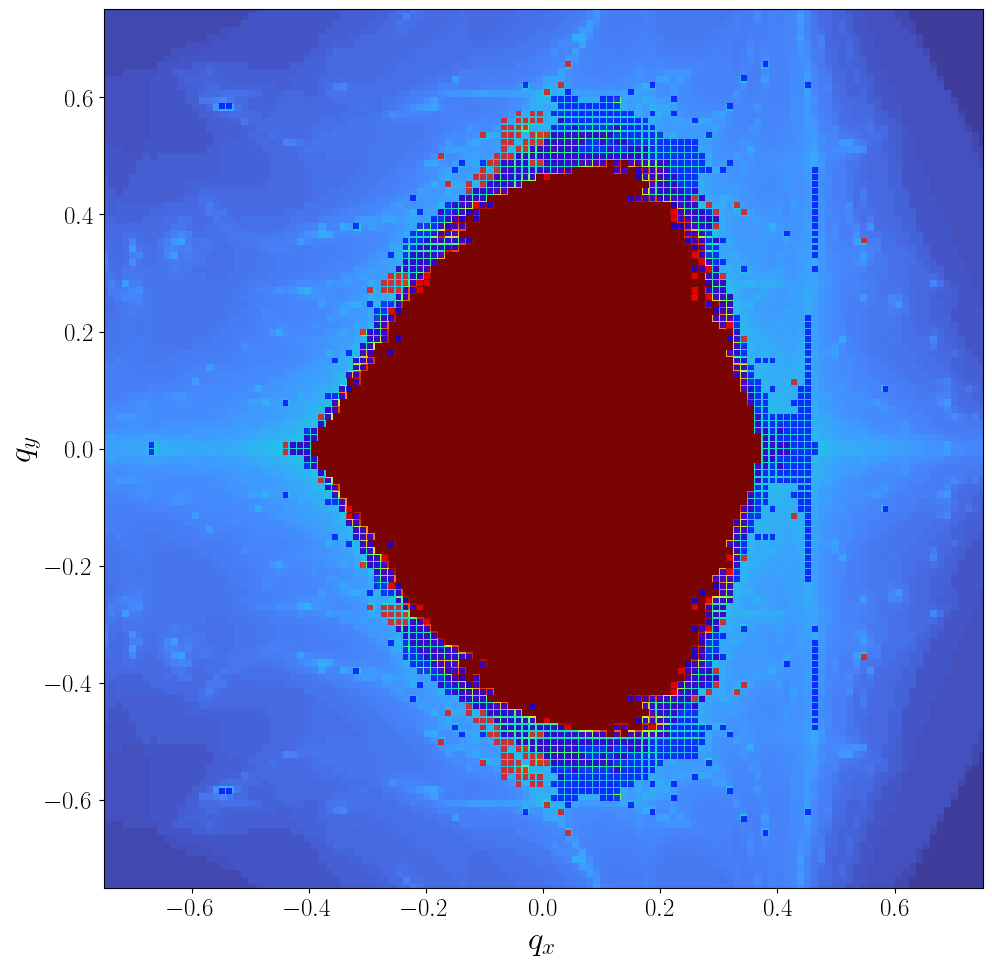

In [11]:
# Plot

fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qxqy_forward + mask_qxqy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
for cx, cy, *_ in xs[select_forward]:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="none", linewidth=0.5, alpha=0.75, zorder=1))
for cx, cy, *_ in xs[select_inverse]:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="none", linewidth=0.5, alpha=0.75, zorder=1))
plt.xlabel('qx')
plt.ylabel('qy')
plt.xlim(-0.75, 0.75)
plt.ylim(-0.75, 0.75)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$q_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [12]:
# Grow the domain (forward)

orbits = np.zeros((len(xs[select_forward]), size, dimension), dtype=np.float64)
scan(xs[select_forward], orbits, orbit(size, threshold, forward4d), knobs)
points_forward = filter(np.vstack(orbits), cut)

domain_forward = Domain(lb, ub, dl)
domain_forward.update(points_forward)

orbits = np.empty((nsamples*npoints, size, dimension), dtype=np.float64)
for epoch in range(64):
    indices = np.random.choice(domain_forward.list, nsamples)
    centers = domain_forward.transform(indices)
    initial = sample(npoints, scale*dl, centers)
    scan(initial, orbits, orbit(size, threshold, forward4d), knobs)
    points = orbits[mask(orbits, threshold)].reshape(-1, dimension)
    points = filter(points, threshold)
    domain_forward.update(points)
    print(f'{epoch + 1:02d}', f'{domain_forward.size:12d}')
    if domain_forward.size > 64_000_000:
        break

01      5755415
02      6387886
03      6782929
04      7105167
05      7366294
06      7582848
07      7767083
08      7958033
09      8088576
10      8227543
11      8384339
12      8552348
13      8763111
14      8945926
15      9147306
16      9324151
17      9468778
18      9625171
19      9778725
20      9917810
21     10031067
22     10169272
23     10274304
24     10378188
25     10498524
26     10602046
27     10691528
28     10775561
29     10868764
30     10966586
31     11046678
32     11154733
33     11236352
34     11322668
35     11394095
36     11463987
37     11534973
38     11611543
39     11689082
40     11773251
41     11848625
42     11915439
43     11978124
44     12052706
45     12117306
46     12188491
47     12253383
48     12316275
49     12383775
50     12447065
51     12506978
52     12565379
53     12625927
54     12683432
55     12742872
56     12802054
57     12859274
58     12914910
59     12970520
60     13027164
61     13082002
62     13135940
63     1

In [13]:
# Grow the domain (inverse)

orbits = np.zeros((len(xs[select_inverse]), size, dimension), dtype=np.float64)
scan(xs[select_inverse], orbits, orbit(size, threshold, forward4d), knobs)
points_inverse = filter(np.vstack(orbits), cut)

domain_inverse = Domain(lb, ub, dl)
domain_inverse.update(points_inverse)

orbits = np.empty((nsamples*npoints, size, dimension), dtype=np.float64)
for epoch in range(64):
    indices = np.random.choice(domain_inverse.list, nsamples)
    centers = domain_inverse.transform(indices)
    initial = sample(npoints, scale*dl, centers)
    scan(initial, orbits, orbit(size, threshold, inverse4d), knobs)
    points = orbits[mask(orbits, threshold)].reshape(-1, dimension)
    points = filter(points, threshold)
    domain_inverse.update(points)
    print(f'{epoch + 1:02d}', f'{domain_inverse.size:12d}')
    if domain_inverse.size > 64_000_000:
        break

01      5916875
02      6543357
03      6982579
04      7284412
05      7492359
06      7706613
07      7901577
08      8037883
09      8182627
10      8309077
11      8438458
12      8648640
13      8788428
14      8978848
15      9195331
16      9356094
17      9559607
18      9721323
19      9838968
20      9951588
21     10087952
22     10208022
23     10320059
24     10431652
25     10551827
26     10653031
27     10736444
28     10827159
29     10916808
30     11016976
31     11119238
32     11205814
33     11295600
34     11377152
35     11453551
36     11537554
37     11611245
38     11684181
39     11754640
40     11824389
41     11895006
42     11958826
43     12027601
44     12099055
45     12161537
46     12231023
47     12295879
48     12380864
49     12443591
50     12501755
51     12559904
52     12619175
53     12682997
54     12752857
55     12809715
56     12864688
57     12922138
58     12980001
59     13032308
60     13092809
61     13146305
62     13200428
63     1

In [14]:
# Check combined domain coverage

n, m = 64, 64
ds, factors = rays(dimension, n, m)

domain = Domain(lb, ub, dl)
domain.insert(domain_forward.keys)
domain.insert(domain_inverse.keys)

keys, *_ = domain.boundary(n, m, center, ds)
flag = np.sum(keys == -1)

print(flag)

4185


In [15]:
# Define forward and inverse domain plane masks (projected)

epsilon = 1.0E-6
width = 1

Qx_forward, Qy_forward, Px_forward, Py_forward = domain_forward.construct.T
mqx_forward = np.abs(Qx_forward) < width*dl + epsilon
mqy_forward = np.abs(Qy_forward) < width*dl + epsilon
mpx_forward = np.abs(Px_forward) < width*dl + epsilon
mpy_forward = np.abs(Py_forward) < width*dl + epsilon

Qx_inverse, Qy_inverse, Px_inverse, Py_inverse = domain_inverse.construct.T
mqx_inverse = np.abs(Qx_inverse) < width*dl + epsilon
mqy_inverse = np.abs(Qy_inverse) < width*dl + epsilon
mpx_inverse = np.abs(Px_inverse) < width*dl + epsilon
mpy_inverse = np.abs(Py_inverse) < width*dl + epsilon

In [16]:
# qx-qy

In [17]:
n = 1000
qx = np.linspace(-1.5, 1.5, n)
qy = np.linspace(-1.5, 1.5, n)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxqy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy, complexity_forward, knobs)

mask_qxqy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy_inverse, complexity_inverse, knobs)

ds = directions(dimension, 256, random=False, ij=(0, 1), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxa, qya, pxa, pya = xs.T

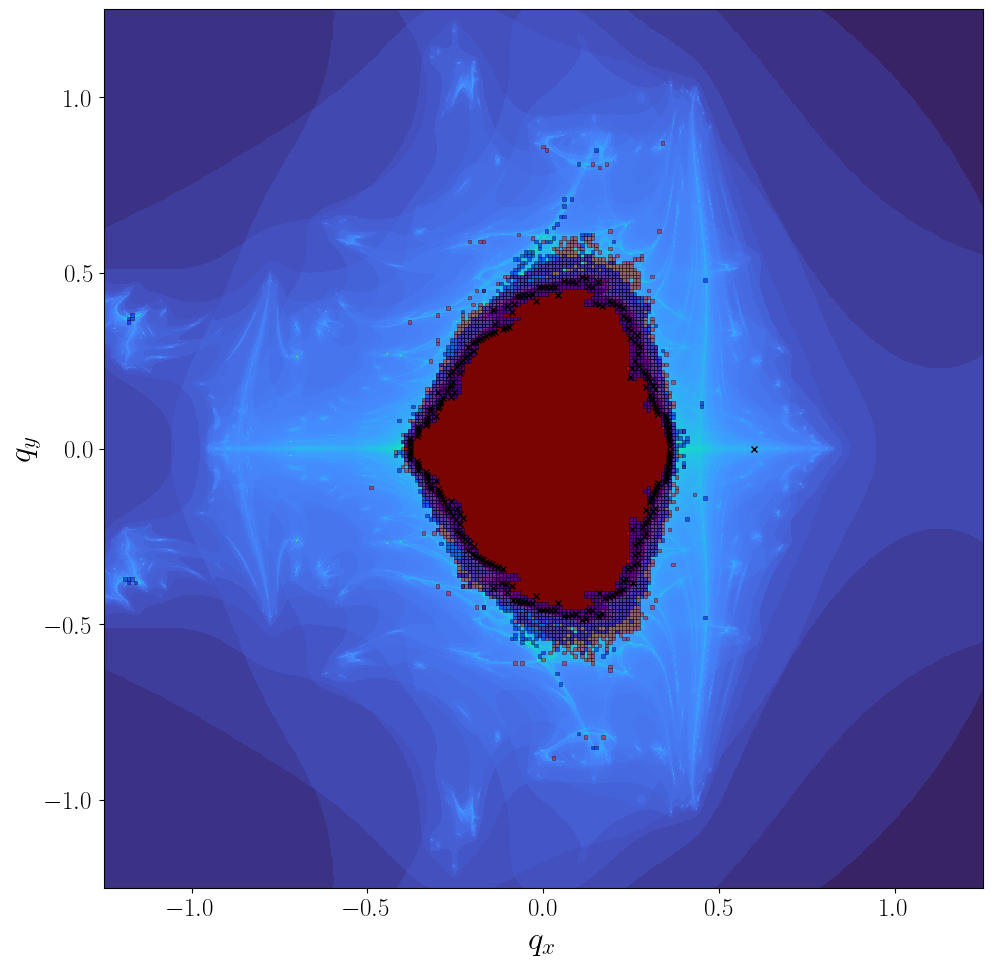

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qxqy + mask_qxqy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_forward[mpx_forward*mpy_forward], Qy_forward[mpx_forward*mpy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_inverse[mpx_inverse*mpy_inverse], Qy_inverse[mpx_inverse*mpy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
ax.errorbar(qxa, qya, color='black', fmt=' ', marker='x', ms=4, zorder=2)
plt.xlabel('qx')
plt.ylabel('qy')
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$q_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [19]:
# qx-px

In [20]:
n = 1000
qx = np.linspace(-1.5, 1.5, n)
px = np.linspace(-1.5, 1.5, n)
qxpx = np.stack(np.meshgrid(qx, px, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qypy = np.full_like(qxpx, 0.0)
qx, px = qxpx.T
qy, py = qypy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxpx = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxpx, complexity_forward, knobs)

mask_qxpx_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxpx_inverse, complexity_inverse, knobs)

ds = directions(dimension, 256, random=False, ij=(0, 2), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxb, qyb, pxb, pyb = xs.T

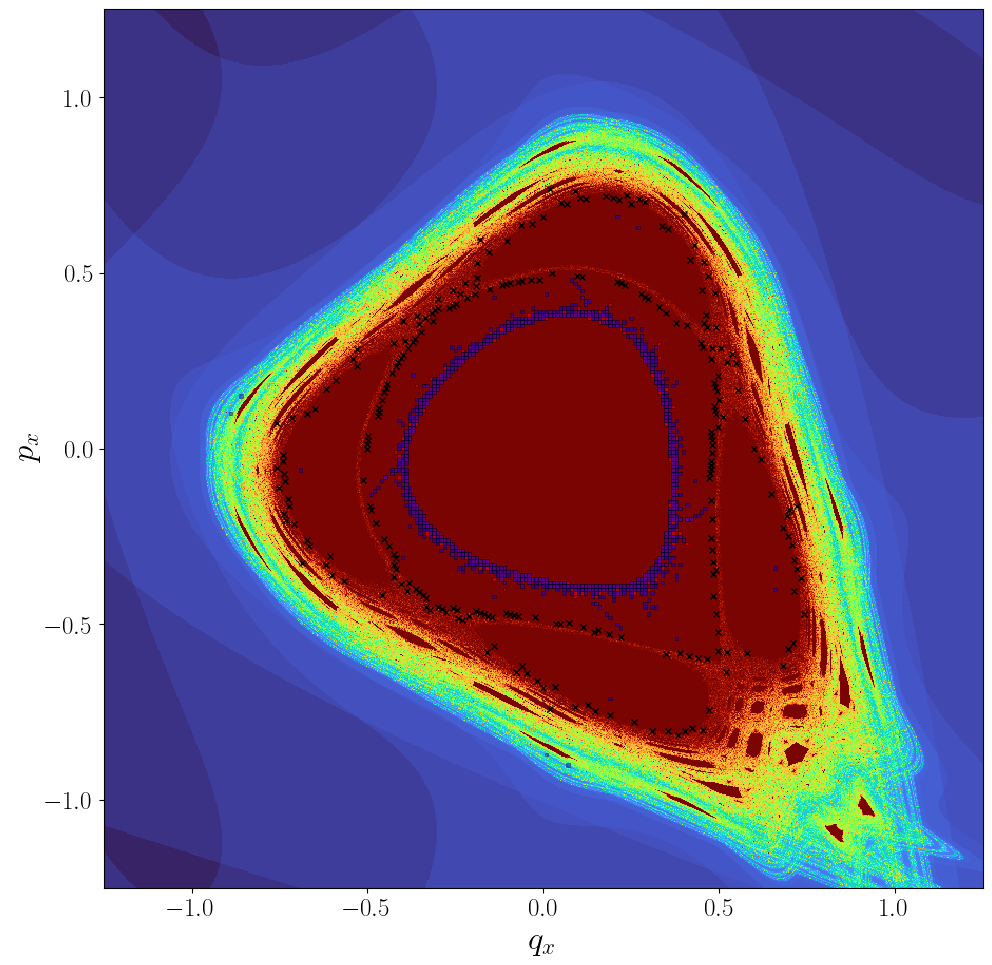

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qxpx + mask_qxpx_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_forward[mqy_forward*mpy_forward], Px_forward[mqy_forward*mpy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_inverse[mqy_inverse*mpy_inverse], Px_inverse[mqy_inverse*mpy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
ax.errorbar(qxb, pxb, color='black', fmt=' ', marker='x', ms=4, zorder=2)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$p_x$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [22]:
# qy-py

In [23]:
n = 1000
qy = np.linspace(-1.5, 1.5, n)
py = np.linspace(-1.5, 1.5, n)
qypy = np.stack(np.meshgrid(qy, py, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qxpx = np.full_like(qypy, 0.0)
qy, py = qypy.T
qx, px = qxpx.T
xs = np.stack([qx, qy, px, py]).T

mask_qypy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qypy, complexity_forward, knobs)

mask_qypy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qypy_inverse, complexity_inverse, knobs)

ds = directions(dimension, 256, random=False, ij=(1, 3), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxc, qyc, pxc, pyc = xs.T

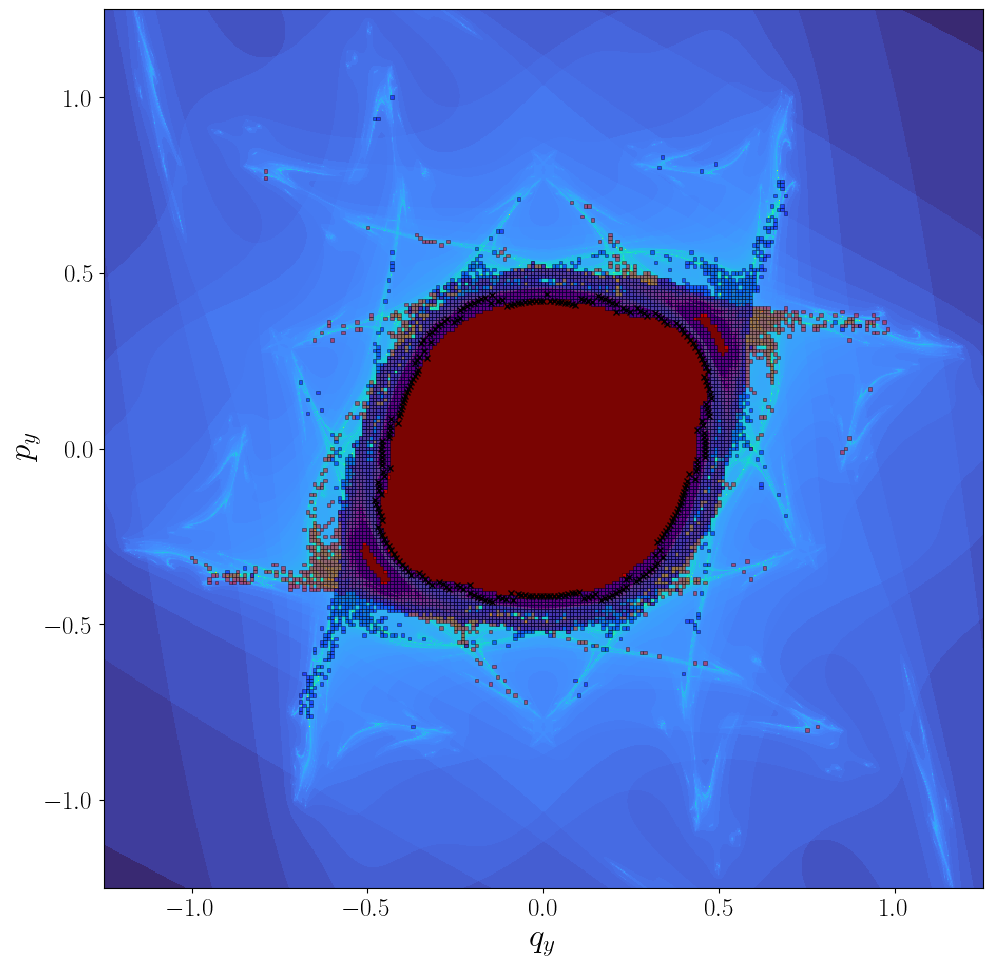

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qypy + mask_qypy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qy_forward[mqx_forward*mpx_forward], Py_forward[mqx_forward*mpx_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qy_inverse[mqx_inverse*mpx_inverse], Py_inverse[mqx_inverse*mpx_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
ax.errorbar(qyc, pyc, color='black', fmt=' ', marker='x', ms=4, zorder=2)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_y$", fontsize=24)
plt.ylabel(r"$p_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [25]:
# px-py

In [26]:
n = 1000
px = np.linspace(-1.5, 1.5, n)
py = np.linspace(-1.5, 1.5, n)
pxpy = np.stack(np.meshgrid(px, py, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qxqy = np.full_like(pxpy, 0.0)
px, py = pxpy.T
qx, qy = qxqy.T
xs = np.stack([qx, qy, px, py]).T

mask_pxpy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_pxpy, complexity_forward, knobs)

mask_pxpy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_pxpy_inverse, complexity_inverse, knobs)

ds = directions(dimension, 256, random=False, ij=(2, 3), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxd, qyd, pxd, pyd = xs.T

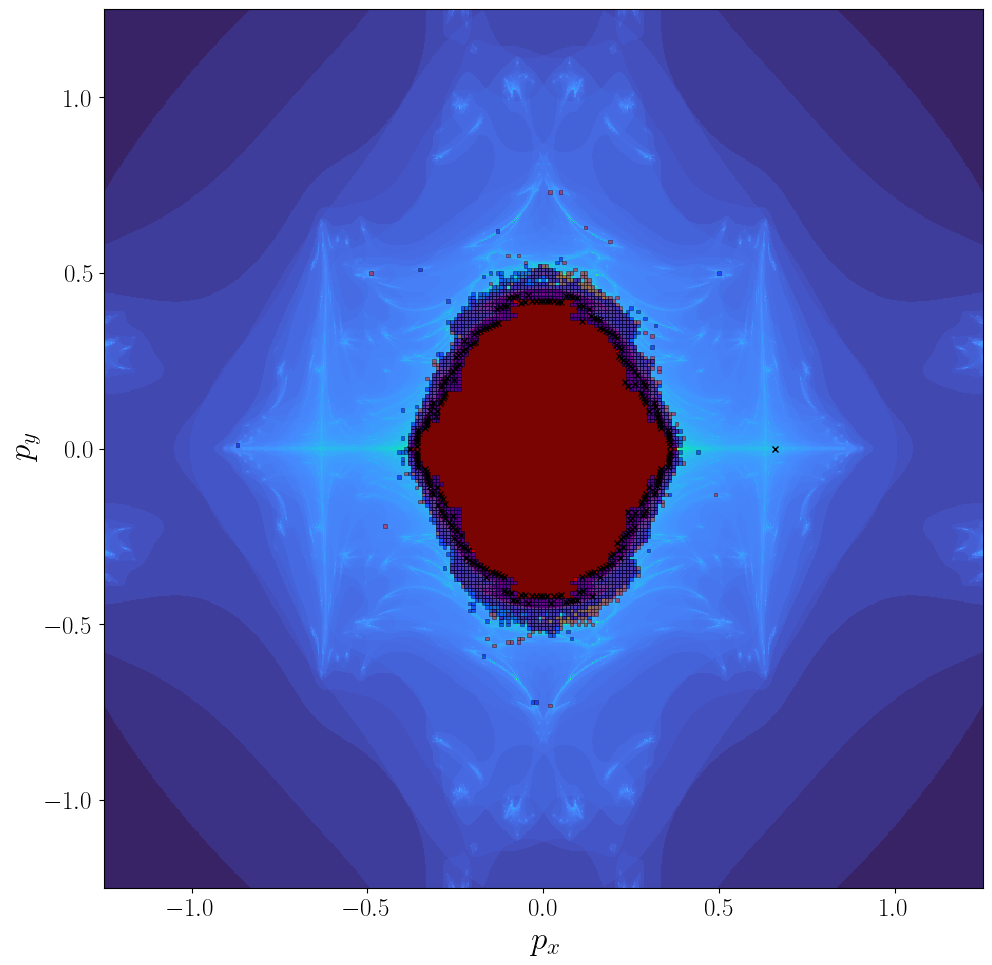

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_pxpy + mask_pxpy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Px_forward[mqx_forward*mqy_forward], Py_forward[mqx_forward*mqy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Px_inverse[mqx_inverse*mqy_inverse], Py_inverse[mqx_inverse*mqy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, zorder=1))
ax.errorbar(pxd, pyd, color='black', fmt=' ', marker='x', ms=4, zorder=2)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$p_x$", fontsize=24)
plt.ylabel(r"$p_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()